In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('customer_transactions.csv', parse_dates=['transaction_date'])
print(f"Raw shape: {df.shape}")

print(df.isnull().sum())          
print(df.duplicated().sum())      

df = df.drop_duplicates()

df['amount'] = df.groupby('category')['amount'].transform(
    lambda x: x.fillna(x.median())
)

df = df[df['amount'] > 0]

Q1, Q3 = df['amount'].quantile([0.25, 0.75])
IQR     = Q3 - Q1
df      = df[df['amount'].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)]

df = df.drop(columns=['true_segment'])

for col, new_col in [('gender','gender_enc'), ('category','category_enc'),
                     ('payment_method','payment_enc'), ('city','city_enc')]:
    le = LabelEncoder()
    df[new_col] = le.fit_transform(df[col])

df['year']       = df['transaction_date'].dt.year
df['month']      = df['transaction_date'].dt.month
df['dayofweek']  = df['transaction_date'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

df.to_csv('clean_transactions.csv', index=False)
print(f"Clean shape: {df.shape}")   # (15913, 17)

Raw shape: (16502, 10)
transaction_id        0
customer_id           0
transaction_date      0
amount              324
category              0
gender                0
age                   0
city                  0
payment_method        0
true_segment          0
dtype: int64
163
Clean shape: (15913, 17)


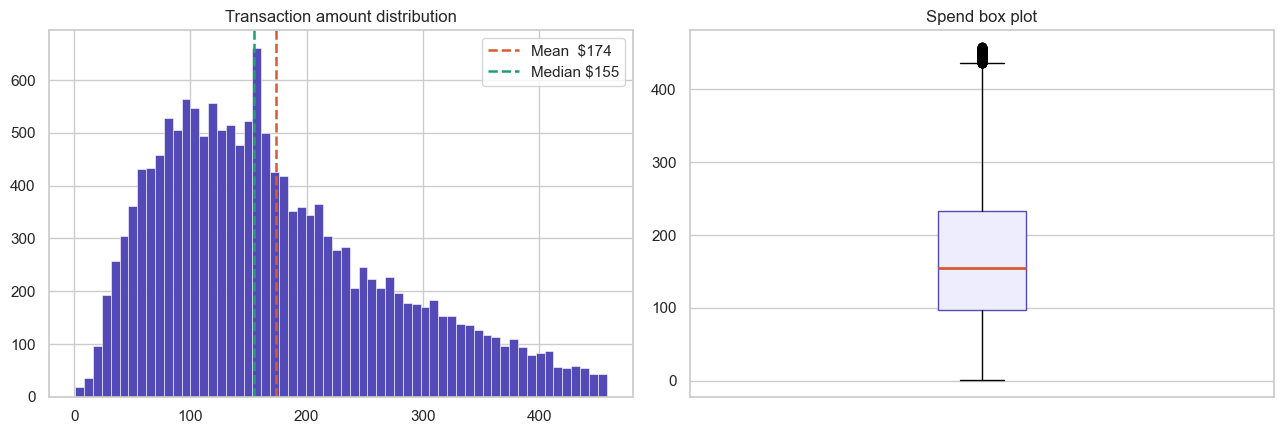

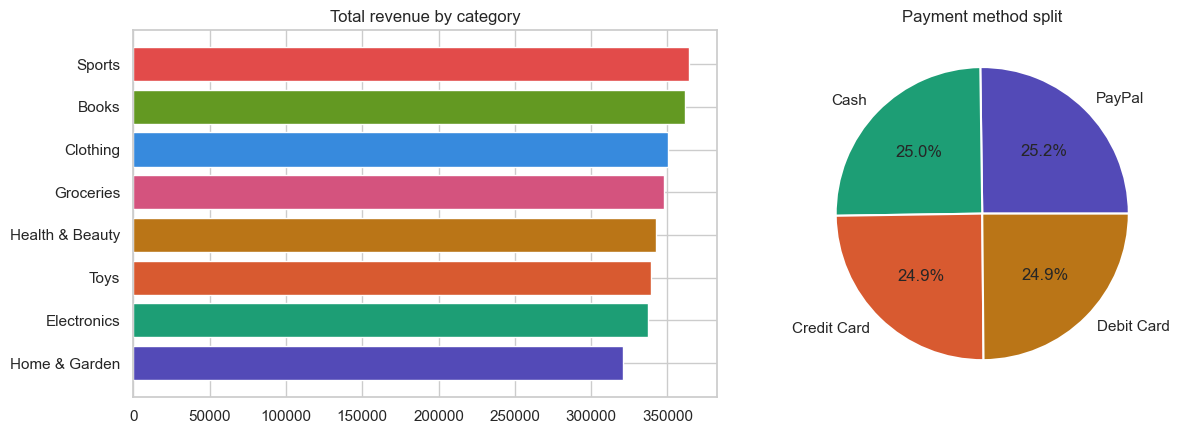

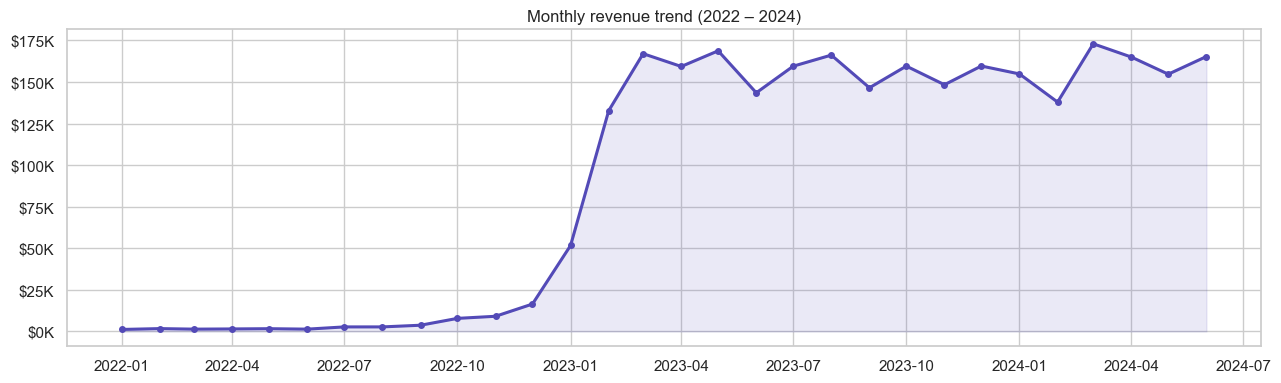

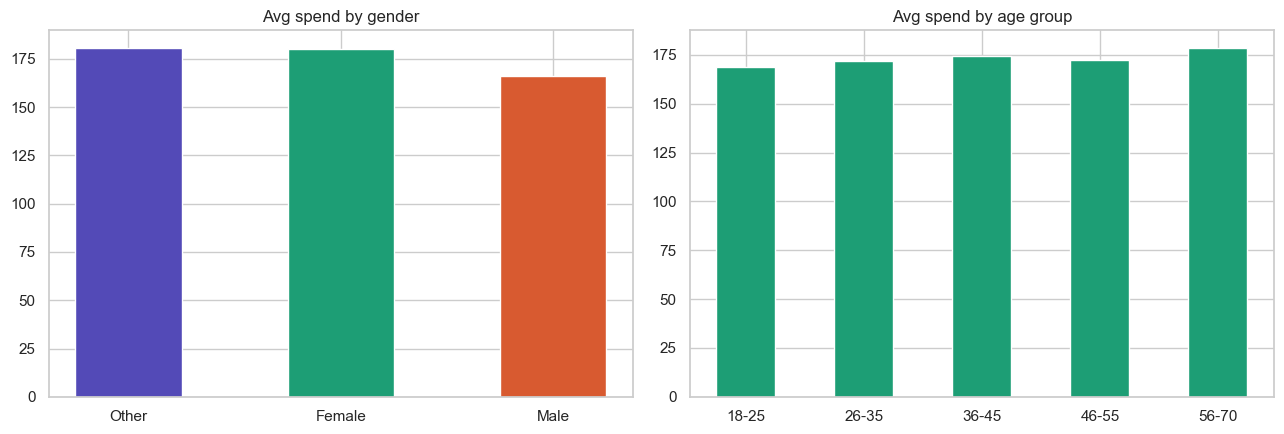

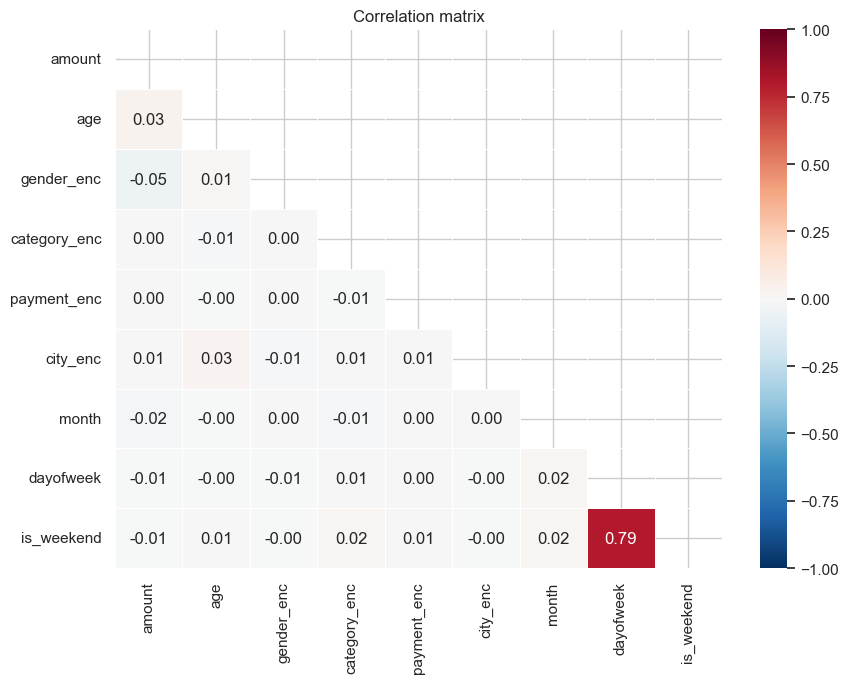

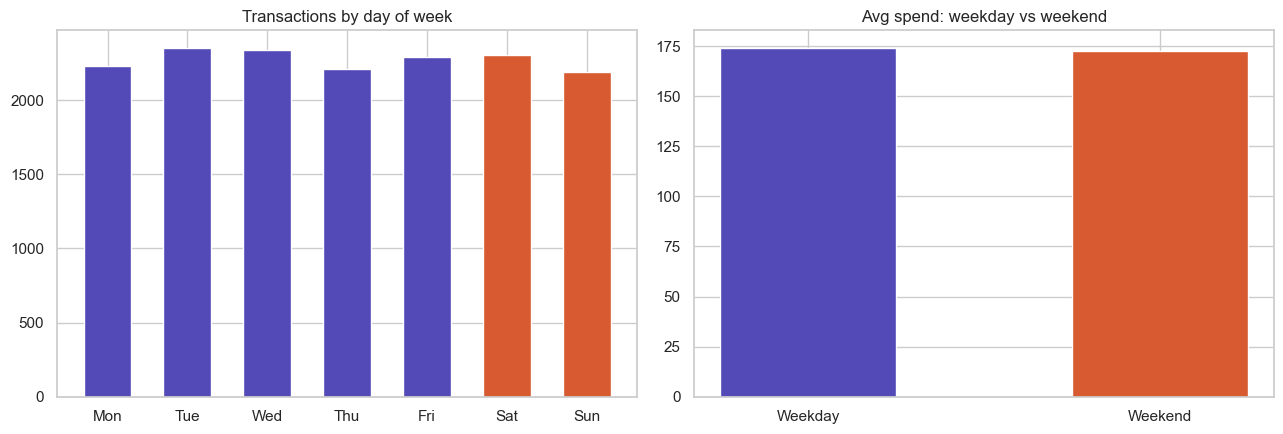

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_transactions.csv', parse_dates=['transaction_date'])
COLORS = ['#534AB7','#1D9E75','#D85A30','#BA7517','#D4537E','#378ADD','#639922','#E24B4A']
sns.set_theme(style='whitegrid', font_scale=1.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['amount'], bins=60, color='#534AB7', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['amount'].mean(),   color='#D85A30', lw=1.8, ls='--', label=f"Mean  ${df['amount'].mean():.0f}")
axes[0].axvline(df['amount'].median(), color='#1D9E75', lw=1.8, ls='--', label=f"Median ${df['amount'].median():.0f}")
axes[0].set_title('Transaction amount distribution'); axes[0].legend()

axes[1].boxplot(df['amount'], patch_artist=True,
                boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),
                medianprops=dict(color='#D85A30', lw=2))
axes[1].set_title('Spend box plot'); axes[1].set_xticks([])
plt.tight_layout(); plt.savefig('eda_01_spend_dist.png', dpi=140, bbox_inches='tight')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cat_rev = df.groupby('category')['amount'].sum().sort_values(ascending=True)
axes[0].barh(cat_rev.index, cat_rev.values, color=COLORS[:len(cat_rev)])
axes[0].set_title('Total revenue by category')

pay_counts = df['payment_method'].value_counts()
axes[1].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
            colors=COLORS[:4], wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Payment method split')
plt.tight_layout(); plt.savefig('eda_02_category_payment.png', dpi=140, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(13, 4))
monthly = df.groupby(df['transaction_date'].dt.to_period('M'))['amount'].sum()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, color='#534AB7', lw=2.2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly.values, alpha=0.12, color='#534AB7')
ax.set_title('Monthly revenue trend (2022 – 2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout(); plt.savefig('eda_03_monthly_trend.png', dpi=140, bbox_inches='tight')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

gender_avg = df.groupby('gender')['amount'].mean().sort_values(ascending=False)
axes[0].bar(gender_avg.index, gender_avg.values, color=['#534AB7','#1D9E75','#D85A30'], width=0.5)
axes[0].set_title('Avg spend by gender')

df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,70],
                          labels=['18-25','26-35','36-45','46-55','56-70'])
age_avg = df.groupby('age_group', observed=True)['amount'].mean()
axes[1].bar(age_avg.index.astype(str), age_avg.values, color='#1D9E75', width=0.5)
axes[1].set_title('Avg spend by age group')
plt.tight_layout(); plt.savefig('eda_04_demographics.png', dpi=140, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(9, 7))
num_cols = ['amount','age','gender_enc','category_enc','payment_enc',
            'city_enc','month','dayofweek','is_weekend']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix')
plt.tight_layout(); plt.savefig('eda_05_correlation.png', dpi=140, bbox_inches='tight')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_counts = df['dayofweek'].value_counts().sort_index()
axes[0].bar(dow_labels, dow_counts.values, color=['#534AB7']*5 + ['#D85A30']*2, width=0.6)
axes[0].set_title('Transactions by day of week')

wk_rev = df.groupby('is_weekend')['amount'].mean()
axes[1].bar(['Weekday','Weekend'], wk_rev.values, color=['#534AB7','#D85A30'], width=0.5)
axes[1].set_title('Avg spend: weekday vs weekend')
plt.tight_layout(); plt.savefig('eda_06_time_patterns.png', dpi=140, bbox_inches='tight')

In [6]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle

df = pd.read_csv('clean_transactions.csv', parse_dates=['transaction_date'])

snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('transaction_date', lambda x: (snapshot_date - x.max()).days),
    frequency = ('transaction_date', 'count'),
    monetary  = ('amount', 'sum'),
).reset_index()

rfm['avg_basket']       = df.groupby('customer_id')['amount'].mean().values
rfm['spend_std']        = df.groupby('customer_id')['amount'].std().fillna(0).values
rfm['unique_categories']= df.groupby('customer_id')['category'].nunique().values
rfm['weekend_ratio']    = df.groupby('customer_id')['is_weekend'].mean().values
lifespan = df.groupby('customer_id')['transaction_date'].agg(
    lambda x: (x.max() - x.min()).days)
rfm['lifespan_days']    = lifespan.values
rfm['purchase_velocity']= rfm['frequency'] / (rfm['lifespan_days'] / 30).replace(0, 1)
rfm['age']              = df.groupby('customer_id')['age'].first().values
rfm['gender_enc']       = df.groupby('customer_id')['gender_enc'].first().values

FEATURE_COLS = ['recency','frequency','monetary','avg_basket','spend_std',
                'unique_categories','weekend_ratio','lifespan_days',
                'purchase_velocity','age','gender_enc']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[FEATURE_COLS])

pca   = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"3 PCs explain: {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

rfm.to_csv('rfm_features.csv', index=False)
np.save('X_scaled.npy', X_scaled)
np.save('X_pca.npy', X_pca)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

3 PCs explain: 71.4% of variance


k=2  inertia=7459  silhouette=0.2680
k=3  inertia=5730  silhouette=0.2878
k=4  inertia=4923  silhouette=0.2401
k=5  inertia=4452  silhouette=0.2453
k=6  inertia=4122  silhouette=0.2232
k=7  inertia=3889  silhouette=0.2177
k=8  inertia=3668  silhouette=0.2162
k=9  inertia=3521  silhouette=0.2028
k=10  inertia=3379  silhouette=0.1898

Best k: 3
Silhouette : 0.2878
Davies-Bouldin : 1.3376
DBSCAN clusters: 1  |  Noise: 0.0%
               recency  frequency  monetary  avg_basket  unique_categories  \
segment_label                                                                
At Risk          11.69      42.36  10693.09      257.59               7.96   
Champions        40.49      15.40   1879.49      108.78               6.38   
Loyal           246.57       2.54    152.94       62.73               2.18   

               purchase_velocity  size  size_pct  
segment_label                                     
At Risk                     2.58   157      15.7  
Champions                   0.91

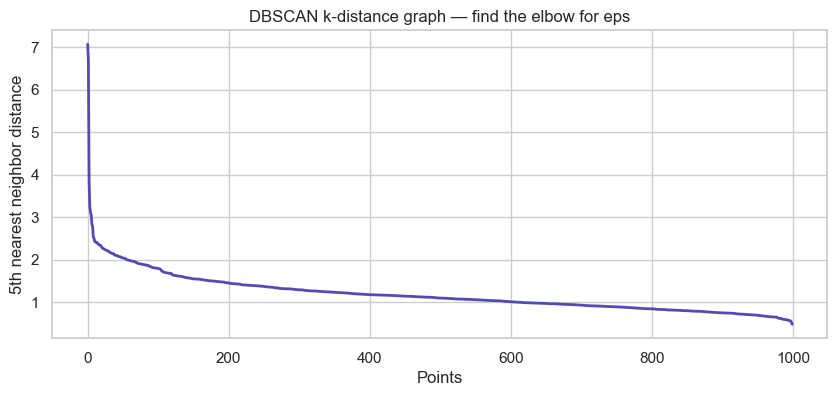

In [8]:

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import pickle

rfm      = pd.read_csv('rfm_features.csv')
X_scaled = np.load('X_scaled.npy')
X_pca    = np.load('X_pca.npy')
LABELS   = {0: 'Champions', 1: 'Loyal', 2: 'At Risk'}

inertias, sil_scores = [], []
for k in range(2, 11):
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={sil_scores[-1]:.4f}")

best_k = list(range(2, 11))[np.argmax(sil_scores)]
print(f"\nBest k: {best_k}")

km_final  = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_scaled)

rfm['segment_km']    = km_labels
rfm['segment_label'] = rfm['segment_km'].map(LABELS)

print(f"Silhouette : {silhouette_score(X_scaled, km_labels):.4f}")
print(f"Davies-Bouldin : {davies_bouldin_score(X_scaled, km_labels):.4f}")

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='#534AB7', lw=2)
plt.title('DBSCAN k-distance graph — find the elbow for eps')
plt.xlabel('Points'); plt.ylabel('5th nearest neighbor distance')
plt.savefig('clust_02_kdist.png', dpi=140, bbox_inches='tight')

db_model  = DBSCAN(eps=7.07, min_samples=5)   
db_labels = db_model.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct  = (db_labels == -1).mean() * 100
print(f"DBSCAN clusters: {n_clusters}  |  Noise: {noise_pct:.1f}%")
rfm['segment_db'] = db_labels

profile = rfm.groupby('segment_label').agg(
    recency           = ('recency', 'mean'),
    frequency         = ('frequency', 'mean'),
    monetary          = ('monetary', 'mean'),
    avg_basket        = ('avg_basket', 'mean'),
    unique_categories = ('unique_categories', 'mean'),
    purchase_velocity = ('purchase_velocity', 'mean'),
    size              = ('customer_id', 'count'),
).round(2)
profile['size_pct'] = (profile['size'] / profile['size'].sum() * 100).round(1)
print(profile)

rfm.to_csv('customer_segments.csv', index=False)
with open('kmeans_model.pkl', 'wb') as f: pickle.dump(km_final, f)
with open('dbscan_model.pkl', 'wb') as f: pickle.dump(db_model, f)